In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

In [2]:
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

BATCH_SIZE = 256
HIDDENS = [256,64]
EPOCHS = 100
WEIGHT_DECAY = 1e-4  # L2 regularization 

In [3]:
def choose_dataset(dataset: str, reduce_labels:bool|int=None, reduce_samples:bool|float=None):  
    '''
    #'MNIST' or 'CIFAR10'; 
    reduce_labels None for the hole labels, an int for the max label to use
    reduce_samples None for the whole dataset, a float between 0 and 1 for the percentage of samples to use
    '''
    transform = transforms.ToTensor() #from uint8 [0,255] to float32 [0,1] and from (H, W, C) to (C, H, W) (channels, height, lenght) and also the class changes

    if dataset=='MNIST':
        train_dataset = datasets.MNIST(root="MNIST", train=True, download=True,transform=transform)#50k images 28x28 black and white
        test_dataset = datasets.MNIST(root="MNIST", train=False, download=True,transform=transform)#10k images

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) #a datatype specific to the library
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False) 
    
    elif dataset=='CIFAR10':
        train_dataset = datasets.CIFAR10(root="CIFAR10", train=True, download=True, transform=transform)#50k images 32x32 rgb
        test_dataset = datasets.CIFAR10(root="CIFAR10", train=False, download=True, transform=transform)#10k images

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) #a datatype specific to the library
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    if reduce_labels is not None: #if reduce_labels not False, reduce the dataset to only the labels <= reduce_labels, for example reduce_labels=2 will only keep labels 0,1,2

        train_idx = [i for i, t in enumerate(train_dataset.targets) if t <= reduce_labels]
        test_idx  = [i for i, t in enumerate(test_dataset.targets) if t <= reduce_labels]

        train_dataset.data = train_dataset.data[train_idx]
        test_dataset.data  = test_dataset.data[test_idx]

    if reduce_samples is not None: #if reduce_samples not False, reduce the dataset 

        train_dataset.data = train_dataset.data[0:int(len(train_dataset.data)*reduce_samples)]
        test_dataset.data  = test_dataset.data[0:int(len(test_dataset.data)*reduce_samples)]

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    return train_dataset, test_dataset, train_loader, test_loader


dataset_name='MNIST'
train_dataset, test_dataset, train_loader, test_loader=choose_dataset(dataset_name, reduce_labels=None, reduce_samples=None)

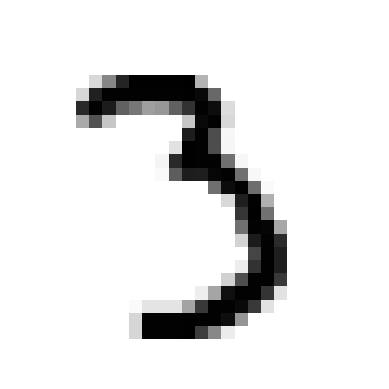

In [4]:
def show_item(index):
    image, label = train_dataset[index] #index not true on train since shuffle

    if image.shape[0] == 1:  #number of channels
        image = image.squeeze(0)
        cmap = 'gray_r'

    else:  # CIFAR10
        image = image.permute(1, 2, 0)
        cmap = None

    plt.imshow(image, cmap=cmap)
    plt.axis('off')
    plt.show()

show_item(7162)

In [5]:
class NeuralNetwork(nn.Module):
    """
    Flexible CNN that optionally adds fully connected heads.
    If `HIDDENS` is empty the network stays fully convolutional.
    """
    def __init__(self, sample_batch, HIDDENS, act=nn.ReLU()):
        super().__init__()

        self.in_channels = sample_batch[0].shape[1]
        self.num_classes = len(torch.unique(sample_batch[1]))
        self.act = act
        self.HIDDENS = HIDDENS
        self.use_fc = len(HIDDENS) > 0

        self.feature_layers = nn.ModuleDict({
            "conv1": nn.Conv2d(self.in_channels, 16, kernel_size=3, padding=0),
            "pool1": nn.MaxPool2d(2, stride=2),
            "conv2": nn.Conv2d(16, 32, kernel_size=3, padding=1),
            "pool2": nn.MaxPool2d(2, stride=2),
            #"conv3": nn.Conv2d(64, 128, kernel_size=3, padding=1),
        })
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
    

        self.conv_channels = [layer.out_channels for layer in self.feature_layers.values() if isinstance(layer, nn.Conv2d)] 
        if self.conv_channels:      #if len(conv_channels)>0, create a descriptor 
            channel_tokens = [str(ch) for ch in self.conv_channels]
            self.conv_descriptor = "conv_" + "-".join(channel_tokens)
        else:
            self.conv_descriptor = "conv_none"

        self.fcs = nn.ModuleList()
        self.conv_head = None

        if self.use_fc:
            with torch.no_grad(): 
                x = sample_batch[0]
                for layer in self.feature_layers.values():
                    x = self.act(layer(x)) if isinstance(layer, nn.Conv2d) else layer(x)
                x = self.global_pool(x)
                flatten_size = x.numel() // x.shape[0]

            layers = []
            in_features = flatten_size
            for hidden_size in HIDDENS:
                layers.append(nn.Linear(in_features, hidden_size))
                in_features = hidden_size
            layers.append(nn.Linear(in_features, self.num_classes))
            self.fcs = nn.ModuleList(layers)
        else:
            last_channels = self.conv_channels[-1] if self.conv_channels else self.in_channels
            self.conv_head = nn.Conv2d(last_channels, self.num_classes, kernel_size=1)

    def forward(self, x, return_hidden=False):
        H = {}

        for name, layer in self.feature_layers.items():
            x = self.act(layer(x)) if isinstance(layer, nn.Conv2d) else layer(x)
            if return_hidden:
                H[name] = x

        if self.use_fc:              #if len(HIDDENS)>0
            x = self.global_pool(x)
            if return_hidden:
                H["global_pool"] = x

            x = x.view(x.size(0), -1)

            for i, layer in enumerate(self.fcs[:-1]):
                x = self.act(layer(x))
                if return_hidden:
                    H[f"fc{i}"] = x

            x = self.fcs[-1](x)
            if return_hidden:
                H[f"fc{len(self.fcs)-1}"] = x
        else:
            x = self.conv_head(x)
            if return_hidden:
                H["conv_head"] = x

            x = self.global_pool(x)
            if return_hidden:
                H["global_pool"] = x

            x = x.view(x.size(0), -1)

        if return_hidden:
            return x, H
        return x

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sample_batch = next(iter(train_loader))  # two data: images and labels, for the first batch
model = NeuralNetwork(sample_batch, HIDDENS, act=nn.Tanh()).to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=WEIGHT_DECAY)  # includes L2 regularization

In [14]:
def train_model(model, loss_function, optimizer, train_loader, test_loader, dataset_name: str,
                 folder_path=os.getcwd(), epochs=EPOCHS, model_name='CNN', collect_hidden=True):

    def append_to_npz(npz_path, array, idx):
        mode = "a" if os.path.exists(npz_path) else "w"
        with zipfile.ZipFile(npz_path, mode=mode, compression=zipfile.ZIP_DEFLATED) as zf:
            name = f"arr_{idx}.npy"
            with zf.open(name, "w") as f:
                np.lib.format.write_array(f, np.asarray(array), allow_pickle=False)

    act_name = type(model.act).__name__
    use_fc = getattr(model, "use_fc", len(getattr(model, "HIDDENS", [])) > 0)

    path = None
    hidden_start_idx = None
    cleared_hidden_files = False

    if collect_hidden:
        hidden_dims = getattr(model, "HIDDENS", [])
        hidden_string = "_".join([f"{dim}-{idx}" for idx, dim in enumerate(hidden_dims)]) if use_fc and hidden_dims else "noFC"
        if hasattr(model, "conv_descriptor"):
            conv_string = model.conv_descriptor
        else:
            conv_channels = [layer.out_channels for layer in model.feature_layers.values() if isinstance(layer, nn.Conv2d)]
            conv_string = "conv_" + "-".join(str(ch) for ch in conv_channels) if conv_channels else "conv_none"
        folder_name = f"{dataset_name}_{model_name}_{conv_string}_{hidden_string}_{act_name}"
        path = os.path.join(folder_path, folder_name)
        os.makedirs(path, exist_ok=True)

    model.train_loss = []
    model.test_loss = []
    model.train_acc = []
    model.test_acc = []

    for epoch in range(epochs):

        model.train()
        train_loss = 0.0
        train_correct = 0
        train_samples = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            pred = model(x)
            loss = loss_function(pred, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            predictions = torch.argmax(pred, dim=1)
            train_correct += (predictions == y).sum().item()
            train_samples += y.size(0)

        train_acc = train_correct / train_samples

        # ----------------------- TEST -----------------------
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_samples = 0

        # store feature maps for this epoch
        H_epoch = {} if collect_hidden else None

        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)

                if collect_hidden:
                    pred, H_batch = model(x, return_hidden=True)

                    items = list(H_batch.items())
                    if hidden_start_idx is None:
                        key_order = [key for key, _ in items]
                        anchor_key = "global_pool"
                        if not use_fc and "conv_head" in key_order:
                            anchor_key = "conv_head"
                        hidden_start_idx = key_order.index(anchor_key) if anchor_key in key_order else 0

                    if not cleared_hidden_files:
                        for key, _ in items[hidden_start_idx:]:
                            npz_path = os.path.join(path, f"{key}.npz")
                            if os.path.exists(npz_path):
                                os.remove(npz_path)
                        cleared_hidden_files = True

                    for key, value in items[hidden_start_idx:]:
                        fm = value.detach().cpu().numpy()
                        fm_flat = fm.reshape(fm.shape[0], -1)
                        if key in H_epoch:
                            H_epoch[key] = np.concatenate((H_epoch[key], fm_flat), axis=0)
                        else:
                            H_epoch[key] = fm_flat
                else:
                    pred = model(x)

                loss = loss_function(pred, y)
                test_loss += loss.item()
                predictions = torch.argmax(pred, dim=1)
                test_correct += (predictions == y).sum().item()
                test_samples += y.size(0)

        test_acc = test_correct / test_samples

        model.train_loss.append(train_loss)
        model.test_loss.append(test_loss)
        model.train_acc.append(train_acc)
        model.test_acc.append(test_acc)

        if collect_hidden:
            for key, value in H_epoch.items():
                npz_path = os.path.join(path, f"{key}.npz")
                append_to_npz(npz_path, value, epoch)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

        if (epoch + 1) % 10 == 0:
            torch.cuda.empty_cache()

    if collect_hidden:
        true_labels = []
        for _, y in test_loader:
            true_labels.append(y.cpu().numpy())
        true_labels = np.concatenate(true_labels, axis=0)

        np.savez(os.path.join(path, 'data'),
                 true_labels=true_labels,
                 train_loss=np.array(model.train_loss, dtype=np.float32),
                 test_loss=np.array(model.test_loss, dtype=np.float32),
                 train_acc=np.array(model.train_acc, dtype=np.float32),
                 test_acc=np.array(model.test_acc, dtype=np.float32))

In [15]:
train_model(model,loss_function, optimizer, train_loader, test_loader,
    dataset_name=dataset_name, epochs=EPOCHS,collect_hidden=True)

Epoch [1/100] | Train Loss: 270.9744 | Test Loss: 21.3714 | Train Acc: 0.5784 | Test Acc: 0.8204
Epoch [2/100] | Train Loss: 107.4667 | Test Loss: 13.1075 | Train Acc: 0.8502 | Test Acc: 0.8947
Epoch [3/100] | Train Loss: 72.7461 | Test Loss: 10.1071 | Train Acc: 0.9010 | Test Acc: 0.9198
Epoch [4/100] | Train Loss: 55.8239 | Test Loss: 8.3972 | Train Acc: 0.9261 | Test Acc: 0.9339
Epoch [5/100] | Train Loss: 48.4713 | Test Loss: 8.0480 | Train Acc: 0.9355 | Test Acc: 0.9370
Epoch [6/100] | Train Loss: 43.2079 | Test Loss: 6.9970 | Train Acc: 0.9426 | Test Acc: 0.9461
Epoch [7/100] | Train Loss: 37.8805 | Test Loss: 6.0428 | Train Acc: 0.9500 | Test Acc: 0.9518
Epoch [8/100] | Train Loss: 36.5025 | Test Loss: 6.2294 | Train Acc: 0.9509 | Test Acc: 0.9495
Epoch [9/100] | Train Loss: 34.6818 | Test Loss: 7.7281 | Train Acc: 0.9535 | Test Acc: 0.9393
Epoch [10/100] | Train Loss: 32.7281 | Test Loss: 5.3137 | Train Acc: 0.9569 | Test Acc: 0.9556
Epoch [11/100] | Train Loss: 29.4212 | Test 

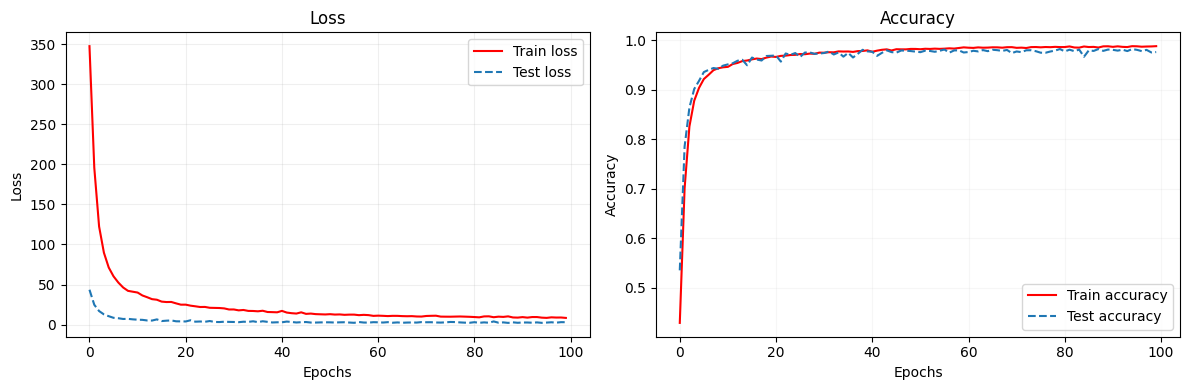

In [9]:
epochs = np.arange(len(model.train_loss))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, model.train_loss, label='Train loss', color='red')
plt.plot(epochs, model.test_loss, label='Test loss', color='tab:blue', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.grid(alpha=0.2)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, model.train_acc, label='Train accuracy', color='red')
plt.plot(epochs, model.test_acc, label='Test accuracy', color='tab:blue', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.grid(alpha=0.1)
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
def inspect_test_image(index):
    image, true_label = test_dataset[index]
    
    image_batch = image.unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(image_batch)
        predicted_label = output.argmax(dim=1).item()
    
    if image.shape[0] == 1:  # MNIST
        image_show = image.squeeze(0)
        cmap = 'gray_r'
    else:  # CIFAR10
        image_show = image.permute(1, 2, 0)
        cmap = None
    
    title = f'Predicted: {predicted_label}, True: {true_label}'
    
    plt.title(title)
    plt.imshow(image_show, cmap=cmap)
    plt.axis('off')
    plt.show()

In [11]:
model.eval()
wrong_indices = []

with torch.no_grad():
    for idx, (image, label) in enumerate(test_dataset):
        pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()
        if pred != label:
            wrong_indices.append(idx)
print(f'wrong indexes on test set: {len(wrong_indices)}')
print(wrong_indices)

wrong indexes on test set: 236
[18, 62, 67, 151, 241, 266, 321, 341, 359, 412, 445, 449, 478, 495, 582, 587, 591, 593, 625, 659, 674, 716, 726, 797, 829, 877, 882, 924, 947, 965, 995, 1014, 1032, 1033, 1050, 1107, 1114, 1167, 1191, 1209, 1232, 1247, 1260, 1299, 1393, 1395, 1441, 1444, 1459, 1569, 1581, 1611, 1618, 1654, 1676, 1681, 1709, 1737, 1871, 1878, 1880, 1901, 1940, 1982, 2035, 2040, 2044, 2107, 2118, 2129, 2130, 2135, 2186, 2189, 2195, 2215, 2280, 2292, 2293, 2308, 2326, 2338, 2363, 2406, 2414, 2422, 2454, 2462, 2556, 2582, 2589, 2597, 2651, 2654, 2754, 2770, 2771, 2802, 2836, 2896, 2939, 2979, 2986, 2995, 3005, 3023, 3060, 3073, 3130, 3164, 3270, 3369, 3511, 3520, 3534, 3558, 3559, 3635, 3654, 3688, 3727, 3742, 3755, 3776, 3778, 3821, 3926, 4078, 4092, 4116, 4163, 4176, 4177, 4205, 4224, 4248, 4284, 4306, 4317, 4321, 4360, 4443, 4449, 4454, 4484, 4497, 4500, 4505, 4523, 4536, 4543, 4547, 4571, 4620, 4662, 4692, 4699, 4738, 4807, 4814, 4838, 4874, 5082, 5209, 5288, 5620, 5634, 

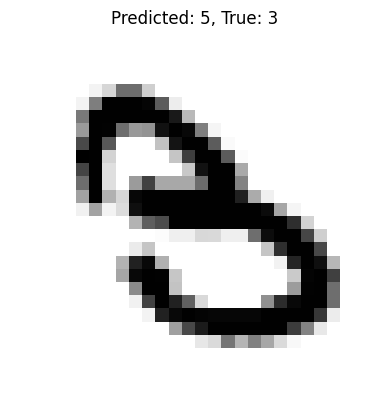

In [16]:
index = 18
inspect_test_image(index)